# Markov approximation at work

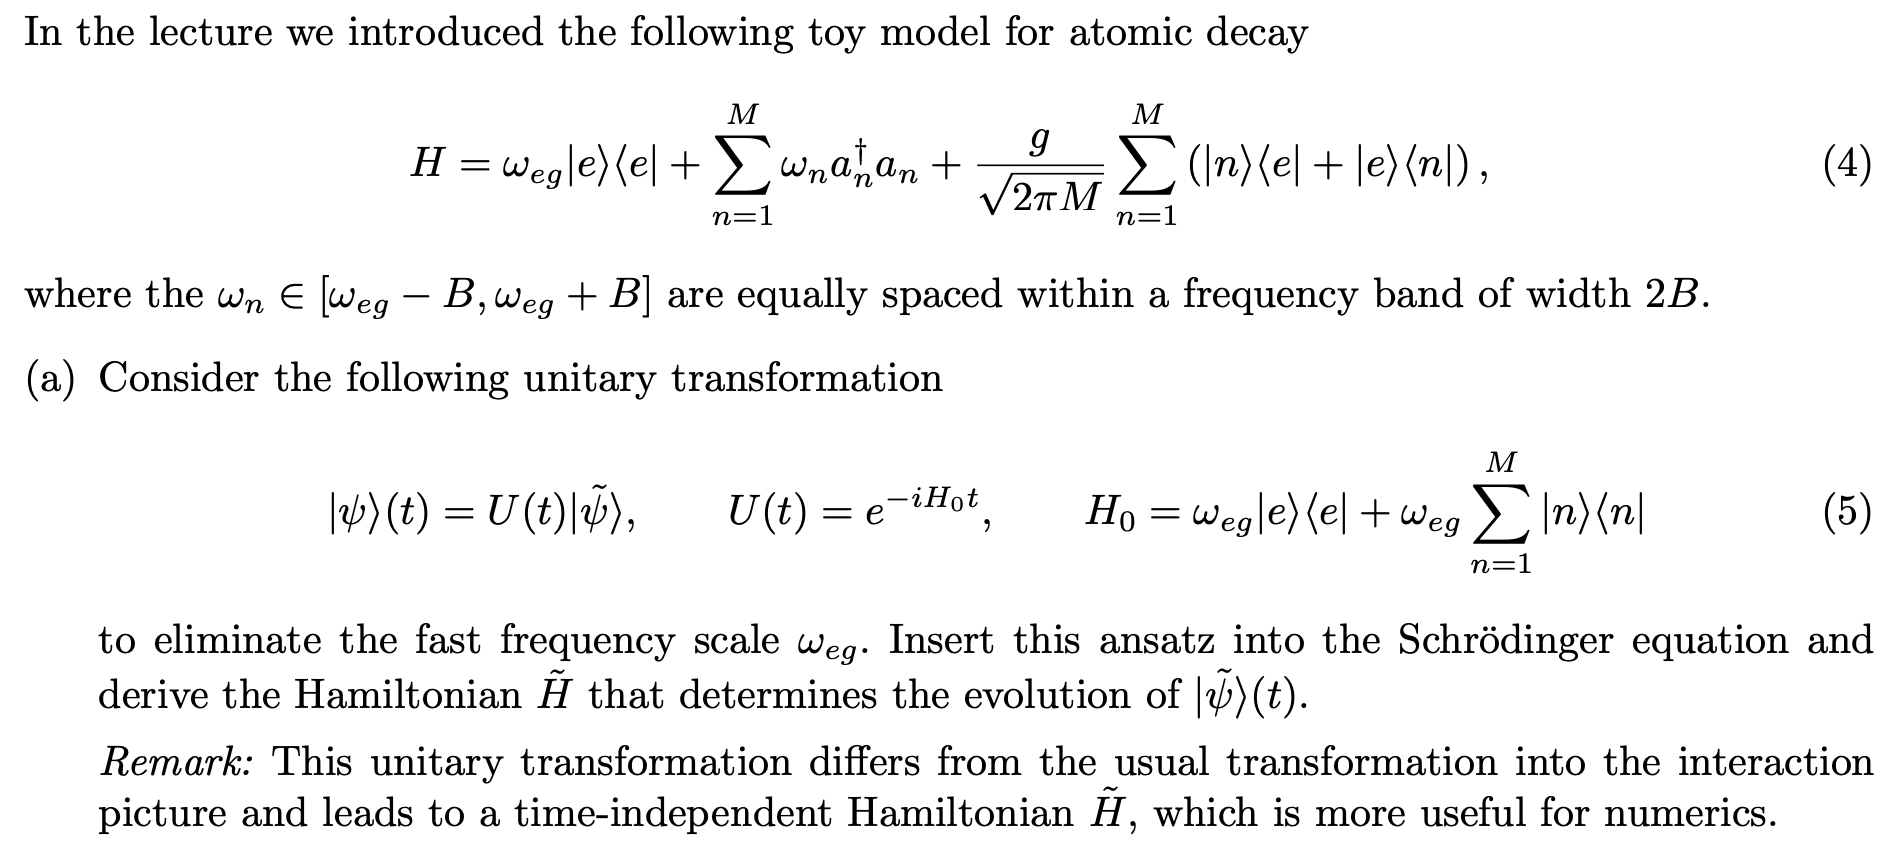

Under the one-excitation approximation I reach the following Hamiltonian:
$$
\sum_{n=1}^M (\omega_n - \omega_{eg}) \ket n \bra n + \frac{g}{\sqrt{2 \pi M}} \left( \ket n \bra e + \ket e \bra n \right)
$$

In [1]:
#importing modules and functions

import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import time

from qutip import Qobj   # use Qobj(A) to generate a better readable output of a matrix or vector A

np.set_printoptions(precision=3)

#nicer latex fonts in plots:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
}) 

In [2]:
def Hamiltonian(M, g, B, sparse=False):
    w_ns = np.linspace(- B, B, M)
    # diagonal elements
    d_elems = np.zeros(M+1)
    d_elems[1:] = w_ns # do not have to substract w_eg if the differences are already centered around zero
    H = np.diag(d_elems)
    # off-diagonal elements
    g_eff = g/np.sqrt(2 * np.pi * M)
    for i in range(1, M+1):
        H[0, i] = g_eff
        H[i, 0] = g_eff
    if sparse:
        H = sp.csr_matrix(H)
    return H

In [3]:
def psidot(t, psi:np.ndarray, H0:np.ndarray, Hdrives:list = []) -> np.ndarray:
    """Function to calculate the time derivative of the state vector psi(t)
    using the time independent Hamiltonian part H0 and the drives Hdrives.

    Parameters
    ----------
    t : float
        time to evaluate the derivative
    psi : np.ndarray
        state vector at time t
    H0 : np.ndarray
        time independent Hamiltonian part
    Hdrives : list
        list of time dependent Hamiltonian parts in the form [(H_drive_1, f_1(t)), (H_drive_2, f_2(t)), ...]
        where f_i(t) is a function of time that multiplies the Hamiltonian H_drive_i.

    Returns
    -------
    np.ndarray
        time derivative of the state vector psi(t)
    """
    # Calculate the time derivative of the state vector psi(t)
    # using the Hamiltonian H0 and the drives Hdrives
    H = H0.copy()
    for H_drive, f in Hdrives:
        H += f(t) * H_drive
    # Calculate the time derivative using the Schrödinger equation
    psidot = -1j * (H @ psi)
    return psidot

In [4]:
# Initial state vector
def initial_state(M):
    """Generate the initial state vector for the system."""
    psi0 = np.zeros(M+1, dtype=complex)
    psi0[0] = 1.0  # Initial state is the ground state
    return psi0

# define parameters
g = 0.5
B = 5.0 # bandwidth of the drive
M = [5, 25, 125, 625] # number of frequency modes
# generate the Hamiltonian
H0_s = [Hamiltonian(m, g, B, sparse=True) for m in M]
# initial state vector
psi0_s = [initial_state(m) for m in M]
# time span for the simulation
t_span = (0, 150)  # from t=0 to t=10

# solve the Schrödinger equation using solve_ivp
# for each Hamiltonian and initial state vector
sols = [solve_ivp(
    psidot, 
    t_span, 
    psi0, 
    args=(H0,), 
    method = 'RK45',  # Runge-Kutta method
    t_eval=np.linspace(t_span[0], t_span[1], 200),  # evaluate at 200 time points
) for H0, psi0 in zip(H0_s, psi0_s)]

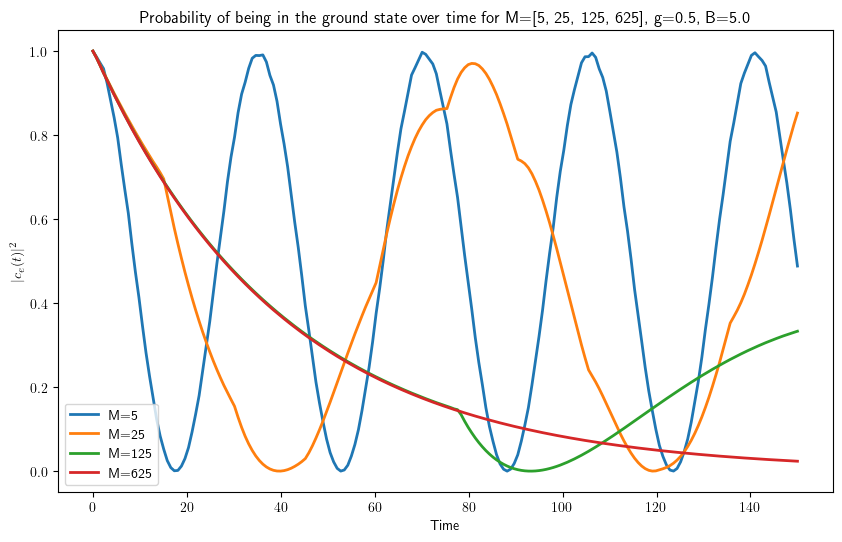

In [5]:
# Plot c_e  over time
fig, ax = plt.subplots(figsize=(10, 6))
for i, (sol, m) in enumerate(zip(sols, M)):
    # Calculate the probability of being in the ground state
    c_e = np.abs(sol.y[0])**2
    ax.plot(sol.t, c_e, label=f'M={m}', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel(r'$|c_e(t)|^2$')
ax.set_title(f"Probability of being in the ground state over time for M={M}, g={g}, B={B}")
ax.legend()



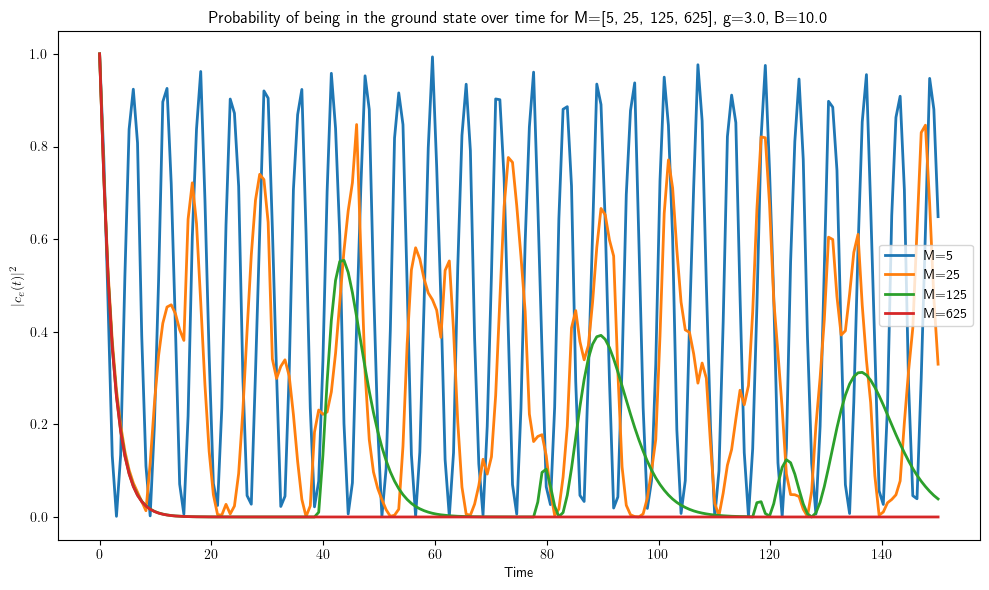

In [6]:
# try also for different g and B values
g = 3.0
B = 10.0 # bandwidth of the drive
# generate the Hamiltonian
H0_s = [Hamiltonian(m, g, B, sparse=True) for m in M]
# initial state vector
psi0_s = [initial_state(m) for m in M]
# time span for the simulation
t_span = (0, 150)  # from t=0 to t=10
# solve the Schrödinger equation using solve_ivp
sols = [solve_ivp(
    psidot, 
    t_span, 
    psi0, 
    args=(H0,), 
    method = 'RK45',  #
    t_eval=np.linspace(t_span[0], t_span[1], 200),  # evaluate at 200 time points
) for H0, psi0 in zip(H0_s, psi0_s)]

# Plot c_e  over time
fig, ax = plt.subplots(figsize=(10, 6))
for i, (sol, m) in enumerate(zip(sols, M)):
    # Calculate the probability of being in the ground state
    c_e = np.abs(sol.y[0])**2
    ax.plot(sol.t, c_e, label=f'M={m}', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel(r'$|c_e(t)|^2$')
ax.set_title(f"Probability of being in the ground state over time for M={M}, g={g}, B={B}")
ax.legend()
fig.tight_layout()
